#### This is a guide to Weather Bench, a climate dataset that helps you understand how to use and understand climate data(sets).

#### Who is this guide for: This guide is designed for those who have completed their first machine learning course.

#### Prerequisites: This guide requires knowledge of Xarray, so if you don't have experience with it, this is a good tutorial to check out: https://tutorial.xarray.dev/overview/xarray-in-45-min.html

#### You will go through some basic code to understand climate datasets and how to get the data from the dataset. You will review data visualizations that visualize various types of data (geopotential data, temperature data, and precipitation data). Then you will create two models using the climate data we have reviewed.

WeatherBench is a "benchmark dataset for data-driven weather forecasting". The data in WeatherBench comes from the ERA5 reanalysis archive. ERA5 is a dataset from the European Centre for Medium-Range Weather Forecasts (ECMWF). More information can be found here https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5


Traditionally, numerical weather prediction (NWP) is a method used to predict weather. This method solves mathematical equations that describe various physical processes across Earth like air flow. The process involved with these physical models involves understanding physical processes on Earth, representing these Earth system processes with mathematical equations, setting initial conditions, representing changing conditions and then solving these mathematical equations again and again. The equations to start off with are the primitive equations; find out more here: https://en.wikipedia.org/wiki/Primitive_equations However, some simulations of processes require too much computing power so scientists use approximations.

Weather predictions are highly reliant on these physical models. But the question is, can AI also be used to train on past data and predict future weather conditions?   

The dataset is made up of hourly data from January 1st, 1979 to December 31st, 2018, over a span of 40 years. WeatherBench has regridded the ERA5 data to lower resolutions as the raw datasets are very large. One vertical level in the raw dataset is around 700 GB worth of data. All the variables we are using are 5.625° (32 latitude values x 64 longitude values) resolution data. This means that the coordinates of the grid differ by 5.625 degrees. Most variable's vertical levels are measured by pressure in hPa.   

There are many different variables included in the WeatherBench data. For example, for the 5.625 degree data, this is the directory structure with examples of the variables you can explore:



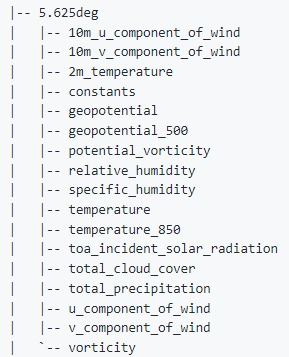





The entirety of the 5.625 degree data (shown above) has a size of 191GB. Each 3 dimensional variable is roughly 25GB each and the 2 dimensional data has a size of about 2GB.

This is the github for Weather Bench: https://github.com/pangeo-data/WeatherBench You can find more information about Weather Bench here and find more advanced tutorials. Find the Weather Bench research paper here: https://arxiv.org/abs/2002.00469 Here is a blog post summarizing Weather Bench and surrounding information: https://raspstephan.github.io/blog/weatherbench/#

#### If you are already familiar with getting the data from a dataset and want to skip to the visualizations, go to the "Visualizing the Data" sections. However, make sure to run the code converting longitude values to -180 to 180 range under the "Understanding the Dataset" section. Otherwise, if you want to go straight to the models, skip to the "Machine Learning Models" header.

### The Weather Bench data is stored in Net CDF files.

Net CDF files are used for storing multi dimensional scientific data. A dataset contains multiple data arrays.

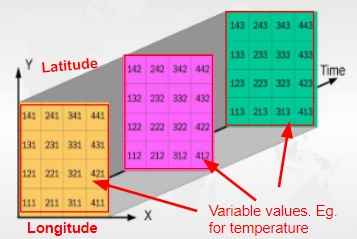

Adopted from https://www.slidestalk.com/u26/reading_netcdf_files_in_matlab_and_analyzing_the_data_eax5pp

This is the structure of our NC file. We have three dimensions: latitude, longitude and time. We have variable values across each moment in time. Weather Bench ranges in time from January 1st, 1979 to December 31st, 2018 on an hourly basis.

### Downloading Modules

In [ ]:
!pip install climetlab

# Once you are done installing, press the button on the top left of the output box which will clear output

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 149 kB 4.3 MB/s 
     |████████████████████████████████| 149 kB 56.1 MB/s 
     |████████████████████████████████| 128 kB 50.4 MB/s 
     |████████████████████████████████| 6.4 MB 57.9 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 56 kB 4.2 MB/s 
     |████████████████████████████████| 73.4 MB 9.4 kB/s 
     |████████████████████████████████| 8.8 MB 45.1 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for climetlab: filename=climetlab-0.11.31-py3-none-any.whl size=214178 sha256=a89425e0fc0fda754ea83d3a87

In [ ]:
!pip install shap
# Once you are done installing, press the button on the top left of the output box which will clear output

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 569 kB 4.3 MB/s 


In [ ]:
!pip install basemap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 864 kB 4.3 MB/s 
     |████████████████████████████████| 30.5 MB 210 kB/s 
     |████████████████████████████████| 46 kB 4.0 MB/s 
     |████████████████████████████████| 6.3 MB 40.0 MB/s 


In [ ]:
# Importing modules
import xarray as xr # Helps make Net CDF files understandable
import matplotlib.pyplot as plt # For making data visualizations
import numpy as np # To understand data values
import pandas as pd # For dataframes
from sklearn.model_selection import train_test_split # To split data into training and test data
from sklearn import metrics # To score our models
import climetlab as cml # To make world maps depicting data
from mpl_toolkits.basemap import Basemap # To make spherical reprensentations of the data on Earth
from sklearn import linear_model # To make our linear regression model
from sklearn.linear_model import LinearRegression # To make our linear regression model
from sklearn.metrics import mean_squared_error # to use mse to score our models
from sklearn.ensemble import RandomForestRegressor # for building the random forest model
from sklearn.model_selection import GridSearchCV # To use for finding the best parameters for our random forest model
from sklearn.tree import export_graphviz # To visualize decision trees
import graphviz # To visualize decision trees
from IPython.display import Image # To visualize decision trees
import sklearn
import shap
%matplotlib inline
import math
from math import sqrt

# Exploring Geopotential

In [ ]:
#Downloading the data through a link (note: it might take a few minutes)
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Fgeopotential_500&files=geopotential_500_5.625deg.zip" -O geopotential_500_5.625deg.zip --no-check-certificate
#Notice where it says geopotential_500 - that is the directory level from the Weather Bench dataset we are downloading!

--2023-07-20 15:16:05--  https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Fgeopotential_500&files=geopotential_500_5.625deg.zip
Resolving dataserv.ub.tum.de (dataserv.ub.tum.de)... 138.246.224.34, 2001:4ca0:800::8af6:e022
Connecting to dataserv.ub.tum.de (dataserv.ub.tum.de)|138.246.224.34|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1532774663 (1.4G) [application/zip]
Saving to: ‘geopotential_500_5.625deg.zip’

geopotential_500_5. 100%[===================>]   1.43G  20.0MB/s    in 72s     

2023-07-20 15:17:19 (20.4 MB/s) - ‘geopotential_500_5.625deg.zip’ saved [1532774663/1532774663]



In [ ]:
# Make a folder for geopotential
!mkdir -p geopotential_500
# Unzip the geopotential_500_5.625deg zip file and place it in the folder we made above
!unzip -d geopotential_500/ geopotential_500_5.625deg.zip

# Notice the year for every file that inflates! These are NetCDF files

Archive:  geopotential_500_5.625deg.zip
  inflating: geopotential_500/geopotential_500hPa_1979_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1980_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1981_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1982_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1983_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1984_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1985_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1986_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1987_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1988_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1989_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1990_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1991_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1992_5.625deg

In [ ]:
# open the dataset, putting it in a variable called z500
z500 = xr.open_mfdataset('geopotential_500/*.nc', combine='by_coords')
# explain parameter, combine

##Understanding the Dataset

## What is geopotential?

Geopotential measures how much work has to be done to raise 1kg from the sea level to that specific height; it is a measurement of air pressure. Air pressure is the weight of air, and the differences in how much the Earth is heated, causes differences in air pressure. The geopotential values are at 500 millibars where you are half way up the atmosphere. Half of atmosphere's height is above you, and half is below you. 500 hPa is at roughly 5.5 km above sea level.

In [ ]:
# Let's explore the geopotential dataset
z500

<xarray.Dataset>
Dimensions:  (lon: 64, lat: 32, time: 350640)
Coordinates:
    level    int32 500
  * lon      (lon) float64 0.0 5.625 11.25 16.88 ... 337.5 343.1 348.8 354.4
  * lat      (lat) float64 -87.19 -81.56 -75.94 -70.31 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 1979-01-01 ... 2018-12-31T23:00:00
Data variables:
    z        (time, lat, lon) float32 dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-10 20:33:23 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

As previously mentioned, the 3 dimensions of the geopotential dataset are lat, lon, and time. There are 64 unique longitude values, 32 unique latitude values, and 350640 unique time values.


Coordinates are a dictionary-like array storing the values of dimensions. The coordinates are used to describe the actual data. For example, lat, lon, level and time is describing geopotential (the actual data).


Attributes describe abitrary metadata.


Find out more here: https://docs.xarray.dev/en/stable/user-guide/data-structures.html#:~:text=There%20are%20two%20types%20of,a%20pandas%20DataFrame%20or%20Series%20.


*   Look at the range of values in each coordinate. For example, time ranges from Jan 1, 1979 to Dec 31, 2018.
*   Longitude values range from 0 to 360, instead of ranging from -180 to 180. This is usual in climate datasets.







In [ ]:
# Let's explore the data variable z

#viewing only the dimensions of z500
print(z500.z.dims)

# data attributes of z
print(z500.z.attrs)

('time', 'lat', 'lon')
{'units': 'm**2 s**-2', 'long_name': 'Geopotential', 'standard_name': 'geopotential'}


Our z variable holds geopotential data! Geopotential's units is measured in m^2 s^−2.

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
z500.coords['lon'] = (z500.coords['lon'] + 180) % 360 - 180
z500 = z500.sortby(z500.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


In [ ]:
# Let's take a look at the data itself
z500.z.data

dask.array<getitem, shape=(350640, 32, 64), dtype=float32, chunksize=(8784, 32, 64), chunktype=numpy.ndarray>

In [ ]:
# To get the actual geopotential values
z500.z.values

array([[[51150.67 , 51150.67 , 51150.67 , ..., 51212.36 , 51181.516,
         51166.094],
        [50163.812, 50194.64 , 50287.17 , ..., 50449.082, 50302.598,
         50202.36 ],
        [50001.906, 50063.58 , 50310.293, ..., 50125.266, 50071.297,
         50032.734],
        ...,
        [51674.95 , 52045.027, 52546.168, ..., 50649.527, 50934.793,
         51243.2  ],
        [51867.7  , 52098.996, 52314.87 , ..., 51058.152, 51343.418,
         51613.26 ],
        [50456.78 , 50518.47 , 50572.438, ..., 50186.938, 50287.17 ,
         50379.688]],

       [[51135.25 , 51135.25 , 51135.25 , ..., 51181.516, 51158.39 ,
         51150.67 ],
        [50163.812, 50210.062, 50318.   , ..., 50425.938, 50287.17 ,
         50186.938],
        [49994.188, 50048.156, 50279.45 , ..., 50094.42 , 50048.156,
         50017.312],
        ...,
        [51682.652, 52052.73 , 52538.445, ..., 50587.855, 50896.246,
         51220.06 ],
        [51875.402, 52122.12 , 52353.418, ..., 51035.027, 51327.996,
   

In [ ]:
# Wonder how many total geopotential values there are?

len(z500.z.data)

350640

In [ ]:
# Values of dimensions

# lat values
print(z500.lat.data,"\n")

#lon values
print(z500.lon.data,"\n") # 0 to 360 value meaning 0 = meridian

# time values
print(z500.time.data,"\n") # notice that time is recorded every hour

[-87.1875 -81.5625 -75.9375 -70.3125 -64.6875 -59.0625 -53.4375 -47.8125
 -42.1875 -36.5625 -30.9375 -25.3125 -19.6875 -14.0625  -8.4375  -2.8125
   2.8125   8.4375  14.0625  19.6875  25.3125  30.9375  36.5625  42.1875
  47.8125  53.4375  59.0625  64.6875  70.3125  75.9375  81.5625  87.1875] 

[-180.    -174.375 -168.75  -163.125 -157.5   -151.875 -146.25  -140.625
 -135.    -129.375 -123.75  -118.125 -112.5   -106.875 -101.25   -95.625
  -90.     -84.375  -78.75   -73.125  -67.5    -61.875  -56.25   -50.625
  -45.     -39.375  -33.75   -28.125  -22.5    -16.875  -11.25    -5.625
    0.       5.625   11.25    16.875   22.5     28.125   33.75    39.375
   45.      50.625   56.25    61.875   67.5     73.125   78.75    84.375
   90.      95.625  101.25   106.875  112.5    118.125  123.75   129.375
  135.     140.625  146.25   151.875  157.5    163.125  168.75   174.375] 

['1979-01-01T00:00:00.000000000' '1979-01-01T01:00:00.000000000'
 '1979-01-01T02:00:00.000000000' ... '2018-12-31T21:0

In [ ]:
# Want to view open a file for a specific year? Open the geopotential folder and copy the file path of the file of the specific year
nineteen_seventy_nine = xr.open_dataset('/content/geopotential_500/geopotential_500hPa_1979_5.625deg.nc')

#Want to view the data?
nineteen_seventy_nine.z.data

## Visualizing the Data

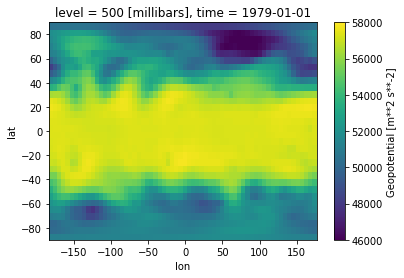

In [ ]:
# Data visualization for earliest data
# z500.z accesses geopotential values
# isel is used for position indexing so time=0 is the first time value
# set_clim sets the range of values in the colour bar
z500.z.isel(time=0).plot().set_clim(46000,58000)

This is a colour plot depicting geopotential levels across the world during the earliest time sample on January 1st, 1979.

Geopotential increases when the weather is warmer. This is because warmer air exerts more pressure. This is why the geopotential levels are higher nearer the equator, where it is warmer.

In the south and north poles, we see that geopotential is lower. We notice though, that the geopotential is lower in the north pole, versus the south pole. In January, the Arctic is experiencing Winter while the Antarctic is in Summer. As a result, the Arctic is colder than the Antarctic, explaining the lower geopotential levels in the North poles. Lower pressure means a lower geopotential height (wintertime) and a higher pressure means a higher geopotential height (summertime).

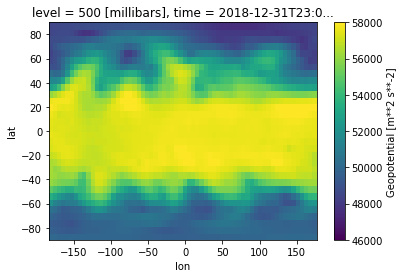

In [ ]:
# Data visualization for latest data on December 31st, 2018
z500.z.isel(time=-1).plot().set_clim(46000,58000)

What can you infer from this data visualization based on what we see in the previous data visualization?

**Why can't we always trust 2d maps?**

Data depicted on a flat plane is often subjected to distortion. On this map, the northern region is stretched and the  equatorial regions are compressed.

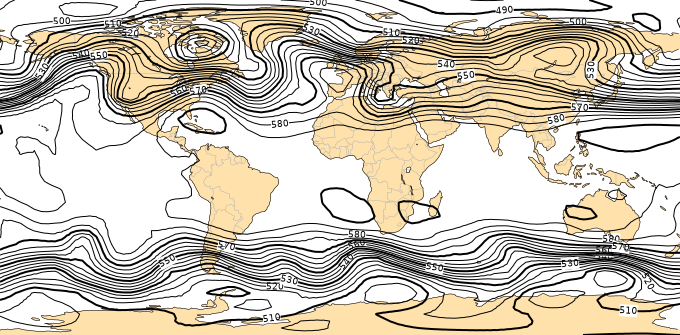

In [ ]:
# Map of geopotential levels and patterns on December 31st, 2018
cml.plot_map(z500.z.isel(time=-1))

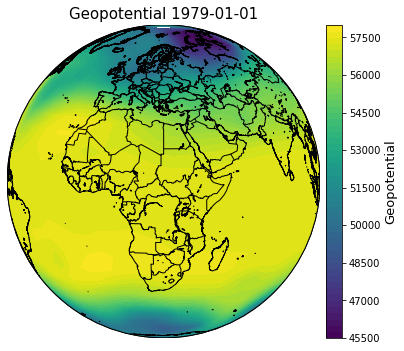

In [ ]:
# create plot
fig = plt.figure(figsize=(6,6))

#create basemap orthographic map projection with intermediate resolution
# to change perspective viewing Earth, change lon_0 and lat_0 values
m = Basemap(projection='ortho', lon_0 = 25, lat_0 = 10, resolution='i')
#assign lat and lon values to x & y
x, y = m(*np.meshgrid(z500.z.lon,z500.z.lat))
#create contour plot with z500 for time = 0 (so the very first time stamp in the data)
cs = m.contourf(x, y,np.squeeze(z500.z.isel(time=0)),levels=50)
m.drawcoastlines()
m.drawmapboundary()
m.drawcountries(linewidth=1,linestyle='solid', color='k')
# Make colourbar variable
cbar = m.colorbar(cs)
cbar.set_label('Geopotential', fontsize=13)
plt.title('Geopotential 1979-01-01', fontsize=15)
plt.show()

This is a spherical representation of the first data visualization we created. This gives us a better understanding of geopotential levels because on a 3D plane, there is no distortion.

There is a central strip of high geopotential because of the warmer temperatures. As you travel north, and there are colder temperatures, geopotential levels drops. We can see this slow increase of geopotential clearly in this countour basemap.

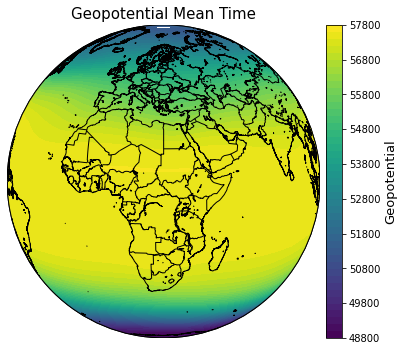

In [ ]:
# create plot
fig = plt.figure(figsize=(6,6))

#create basemap orthographic map projection with intermediate resolution
m = Basemap(projection='ortho', lon_0 = 25, lat_0 = 10, resolution='i')
#assign lat and lon values to x & y
x, y = m(*np.meshgrid(z500.z.lon,z500.z.lat))
#create contour plot with z500 for mean time
cs = m.contourf(x, y,np.squeeze(z500.mean("time").z),levels=50)
m.drawcoastlines()
m.drawmapboundary()
m.drawcountries(linewidth=1,linestyle='solid', color='k')
# Make colourbar variable
cbar = m.colorbar(cs)
cbar.set_label('Geopotential', fontsize=13)
plt.title('Geopotential Mean Time', fontsize=15)
plt.show()


This visualization shows geopotential values over mean time.

As we mentioned before, colder tempeartures means lower geopotential temperatures, which is why we see darker colours in the North and South Poles.

Antarctica is a lot colder than the Arctic. The South Pole's elevation is 9000 feet while the North Pole is at sea level. Antarctic has more ice; the Antarctic Ice sheet is 8 times the size of the Greenland Ice Sheet in the Arctic (the second largest ice sheet). Antarctica is a contient surrounded by the Southern Ocean. The Arctic is an ocean that is surrounded by land masses.

This explains the darker purple spot we see in the South Pole that we don't see in the North Pole.

Find out more: https://www.auroraexpeditions.com.au/blog/why-is-antarctica-colder-than-the-arctic/

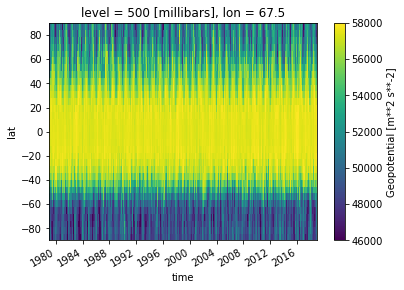

In [ ]:
# Viewing the data for a specific lon over years
z500.z.sel(lon=67.5).plot(x="time").set_clim(46000,58000)

The darker colour in the South Pole, meaning lower geopotential values, is due to the colder temperatures found in the South Pole. The pattern of lines that we see show seasonal changes in geopotential, due to seasonal changes in temperature.  

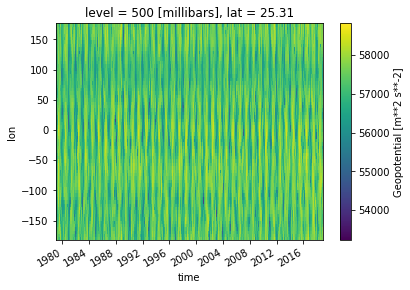

In [ ]:
# Maybe you want to see a data visualization for a specific lat over time
z500.z.sel(lat=25.3125).plot(x="time")

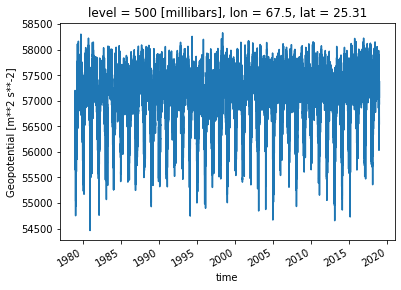

In [ ]:
# Plotting for a specific set of lat and lon to view yearly patterns
z500.z.sel(lat=25.3125,lon=67.5).plot(x="time");

This location is a place in Sindh, Pakistan. This location is near to the equator (and looking at the visualizations we created earlier), we know that the location falls into the yellow, signifying high geopotential values. This makes sense, looking at the graph where we see that most of the time, geopotential levels are quite high. There are a few line drops, likely during the wintertime - for example, from 1980-1985, a duration of 5 years, we see exactly 5 line drops, each one during the winter season every year.

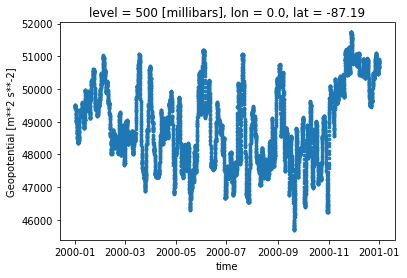

In [ ]:
# Viewing geopotential levels over the span of a year
z500.sel(lat=-87.1875,lon=0,time="2000").plot.scatter(x="time",y="z",s=7);

The latitude value is very near to -90, meaning this is in Antarctica. (The negative value means this is in the southern hemisphere). We see a lot of fluctuations over the year in geopotential values. Geopotential levels are in the range of 46000-52000 so we can tell that this location has lower geopotential levels. The maximum geopotential value that we see on Earth is around 58000, and a lot of the equatorial regions are usually at this value. We can also assume, because of the lower geopotential levels, that this is a colder place; this makes sense, because the graph depicts Antarctica.  

Challenge: **Can you plot geopotential values over a year at your favourite city to visit?**

Text(0.5, 1.0, 'May 1, 1979')

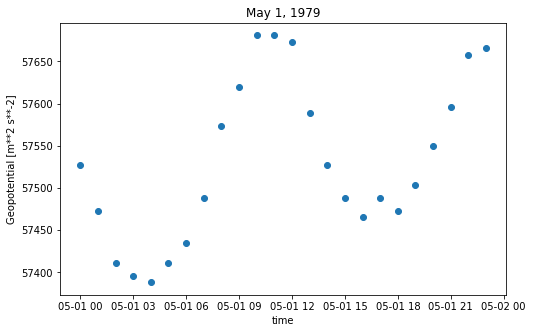

In [ ]:
# specific day

# May 1st, 1979
plt.figure(figsize=(8,5))
z500.sel(lat=2.8125,lon=0,time="1979-05-01").plot.scatter(x="time",y="z");
plt.title("May 1, 1979")

This is a location close to the equator, on the Greenwich line. We see geopotential levels fluctuate throughout the course of a day.


Challenge: **Can you plot the geopotential values on your birthday at your favourite city to visit?**

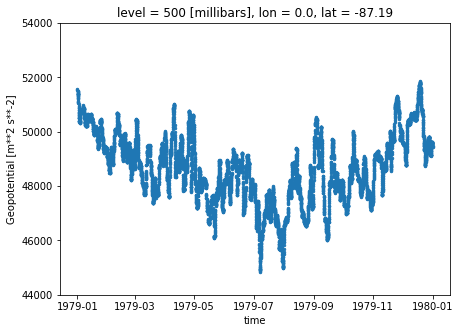

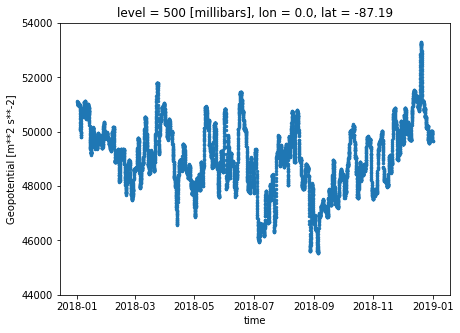

In [ ]:
# Compare seasonal changes between 1979 and 2018

# earliest year at specific location
plt.figure(figsize=(7,5))
plt.ylim(44000,54000)
z500.sel(lat=-87.1875,lon=0,time="1979").plot.scatter(x="time",y="z",s=6)

# earliest year at specific location
plt.figure(figsize=(7,5))
plt.ylim(44000,54000)
z500.sel(lat=-87.1875,lon=0,time="2018").plot.scatter(x="time",y="z",s=6)


This data visualization depicts seasonal changes of geopotential values across a year. The first visualization is 1979, and the second is 2018; that is a 39 year difference. Generally, there are higher geopotential levels in 2018. This could be due to warmer temperatures across 2018, due to global warming.

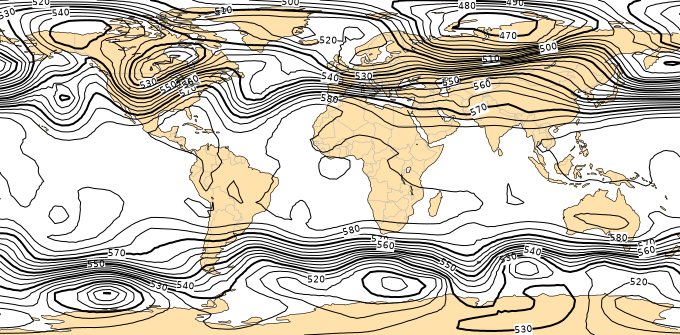

In [ ]:
cml.plot_map(z500)

Challenge: **Can you create a world map depicting geopotential values on a date that is important to you?**

(hint: the .sel function)

In [ ]:
# Normalizing the dataset
mean = np.mean(z500.z.values)
std = np.std(z500.z.values)

z500_n = (z500-mean)/ std

Text(0.5, 1.0, '2018 Normalization')

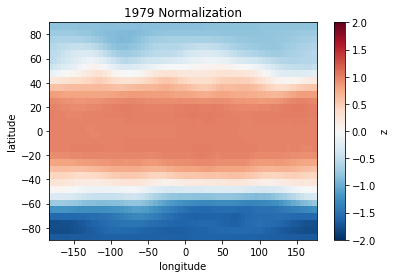

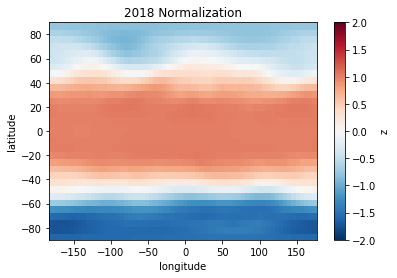

In [ ]:
# Plot a data visualizations that compares geopotential values in 1979 and 2018, by taking their mean

plt.figure()
# Select 1979, find the mean, storing it in a variable called y1979
y1979 = ((z500.sel(time="1979"))).mean('time')
# Normalize the data by subtracting the mean from y1979 and dividing by the standard deviation
y1979 = (y1979-mean)/std
# Plot!
y1979.z.plot().set_clim(-2,2)
plt.title("1979 Normalization")

plt.figure()
# Select 2018, find the mean, storing it in a variable called y2018
y2018 = ((z500.sel(time="2018"))).mean('time')
# Normalize the data by subtracting the mean from y2018 and dividing by the standard deviation
y2018 = (y2018-mean)/std
# Plot
y2018.z.plot().set_clim(-2,2)
plt.title("2018 Normalization")

When you see a difference in normalization values, you know that there is an abnormality or that something has changed.

Text(0.5, 1.0, 'Time = 2018-12-31')

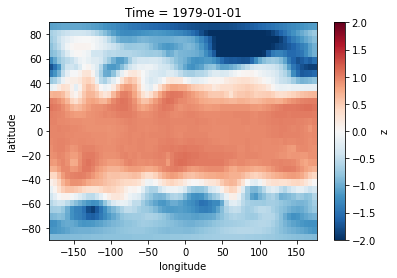

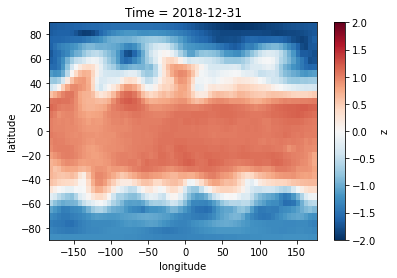

In [ ]:
# Normalization for a specific day

plt.figure()
z500_n.z.isel(time=0).plot().set_clim(-2,2)
plt.title("Time = 1979-01-01")
plt.figure()
z500_n.z.isel(time=-1).plot().set_clim(-2,2)
plt.title("Time = 2018-12-31")

Take some time to explore yourself and make some data visualizations!

# Exploring Total Precipitation

We will be taking a look at another directory level in the Weather Bench dataset - total precipitation!

In [ ]:
#downloading the data
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftotal_precipitation&files=total_precipitation_5.625deg.zip" -O total_precipitation_5.625deg.zip --no-check-certificate

--2022-09-11 20:08:30--  https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftotal_precipitation&files=total_precipitation_5.625deg.zip
Resolving dataserv.ub.tum.de (dataserv.ub.tum.de)... 138.246.224.34, 2001:4ca0:800::8af6:e022
Connecting to dataserv.ub.tum.de (dataserv.ub.tum.de)|138.246.224.34|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1912945347 (1.8G) [application/zip]
Saving to: ‘total_precipitation_5.625deg.zip’

total_precipitation 100%[===================>]   1.78G  18.2MB/s    in 1m 41s  

2022-09-11 20:10:13 (18.1 MB/s) - ‘total_precipitation_5.625deg.zip’ saved [1912945347/1912945347]



In [ ]:
# making total precipitation folder
!mkdir -p total_precipitation
#unzipping the total precipitation zip file
!unzip -d total_precipitation/ total_precipitation_5.625deg.zip

Archive:  total_precipitation_5.625deg.zip
  inflating: total_precipitation/total_precipitation_1979_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1980_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1981_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1982_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1983_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1984_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1985_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1986_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1987_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1988_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1989_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1990_5.625deg.nc  
  inflating: total_precipitation/total_precipitation_1991_5.625deg.nc  
  inflating: total_pr

##Understanding the Dataset

In [ ]:
# Open the dataset
total_precip = xr.open_mfdataset('total_precipitation/*.nc', combine='by_coords')
total_precip

In [ ]:
total_precip.tp.attrs

{'units': 'm', 'long_name': 'Total precipitation'}

The variable tp represents total precipitation in metres.

In [ ]:
# View the dimensions of tp (what values help describe the total precipitation values?)
total_precip.tp.dims

('time', 'lat', 'lon')

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
total_precip.coords['lon'] = (total_precip.coords['lon'] + 180) % 360 - 180
total_precip = total_precip.sortby(total_precip.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


In [ ]:
# Let's view the data
total_precip.tp.data

In [ ]:
# What do the actual total precipitation values look like?
total_precip.tp.values

Woah! These are really small numbers.

###Visualizing the Data

In [ ]:
plt.figure()
# earliest precipitation levels
total_precip.tp.isel(time=0).plot();

# latest precipitation levels
plt.figure()
total_precip.tp.isel(time=-1).plot();

We see that there is the most rainfall in the equatorial regions. The equatorial regions generally get the highest amount of rain than anywhere on Earth; one reason for this is that air masses converge here causing heavy rainfall. Plus, air movement causes warm air to rise from the equator and come back down in the subtropics ((-)30 to (-)40 degrees), causing precipitation.


In [ ]:
# World Map representations of the data above

# 1979-01-01
print("1979-01-01")
cml.plot_map(total_precip.tp.isel(time=0),foreground=dict(map_grid=False,map_boundaries=True, map_boundaries_thickness = 2))
print("\n")
#2018-01-01
print("2018-01-01")
cml.plot_map(total_precip.tp.isel(time=-1),foreground=dict(map_grid=False,map_boundaries=True, map_boundaries_thickness = 2))

1979-01-01


NameError: ignored

Notice that there is a lot of rain in the equatorial regions. Specifically, notice that there is a lot of rain in South America, Indonesia and Malaysia. There is a lot of rain by coastlines and coastal areas. For example, there is a lot of precipitation by the Great Lakes.

Climate models predict that as a result of increasing temperatures, Earth will see a subsequent increase in evaporation. This means intense storms will occur more frequently but some areas will experience drying. Areas getting these intense storms will have higher precipitation and a greater risk of flooding while areas that are subjected to drying have a greated chance of droughts due to the lower precipitation.

Challenge: **What is your most favourite city to travel to? How much rainfall does it get? Can you create a data visualization depicting this?**

(hint: Take a look at code we used before when exploring geopotential)

In [ ]:
# create plot
fig = plt.figure(figsize=(6,6))

#create basemap orthographic map projection with intermediate resolution
m = Basemap(projection='ortho', lon_0 = -90, lat_0 = 10, resolution='i')
#assign lat and lon values to x & y
x, y = m(*np.meshgrid(total_precip.tp.lon,total_precip.tp.lat))
#create contour plot with z500 for mean time
cs = m.contourf(x, y,np.squeeze(total_precip.mean("time").tp),levels=50)
m.drawcoastlines()
m.drawmapboundary()
m.drawcountries(linewidth=1,linestyle='solid', color='k')
# Make colourbar variable
cbar = m.colorbar(cs)
cbar.set_label('Total Precipitation [m]', fontsize=13)
plt.title('Total Precipitation Mean Time', fontsize=15)
plt.show()

Notice that bright yellow stripe around the equator? That is the Intertropical Convergence Zone (ITCZ). This is a zone where the Northern and Southern hemispheres' trade winds converge. The equator's warm waters and large amount of direct sunlight, heats the air in this zone, increasing humidity. The warm air rises with the help of the trade winds that are converging here, and then expands and cools. This results in a lot of rainfall.

To gain a deeper understanding of precipitation patterns and what we see in the data visualization, take a look here: https://precipitation-patterns.zoec27.repl.co/

In [ ]:
plt.figure()
total_precip.mean("time").tp.plot()

Notice the pretty clear yellow line - it makes sense that this area recieves the most amount of rainfall as this is where the Intertropical Convergence Zone is. Can you make out the split between South America and North America where the bright yellow line passes through? The Atlantic Ocean gets a lot of rainfall generally. On the far right side (edge of the visualization), we see patches of yellow, where the Atlantic Ocean is.

*For the next 2 graphs, taking a looking at this world map with lat and lon coordinates will help you better intrepret the graphs:*

https://th.bing.com/th/id/R.33f010793b51c6460ee76a3eb96fdd47?rik=lEBbJGUSkf2hbw&riu=http%3a%2f%2fwww.svsarana.com%2foscar%2fworld-lat-lon.png&ehk=ng%2fHHG6G%2fnUxM0ohcrhuBED1nK%2ftqbdn2UbW4AvPV9U%3d&risl=&pid=ImgRaw&r=0&sres=1&sresct=1

In [ ]:
# This graph takes the mean of latitude and time to get the average geopotential values for each longitude
plt.figure()
total_precip.mean(["lat", "time"]).tp.plot();

The first bump in the graph is the Pacific Ocean. The second bump (with multiple spikes) is the Atlantic Ocean. The last bump is the Pacific Ocean.

In [ ]:
# This graph takes the mean of longitude and time to get the average geopotential values for each latitude
plt.figure()
total_precip.mean(["lon", "time"]).tp.plot();

Challenge: **What is this graph depicting? What does the large bump at 0 latitude mean? What do the bumps mean?**

Hint: 0 latitude is the equator, and the graph shows us that it receives a lot of rainfall. Knowing that equatorial regions receive the most rainfall than anywhere else on Earth, this graph confirms what we know.

In [ ]:
# Precipitation of mean time
cml.plot_map(total_precip)

####Where are some places that get a lot of rain? Notice how most of the rain is either over the ocean, or around coastlines. Do you remember the visualization of rainfall patterns? Can you recognize some of those places on this map?

Remember some of the data visualizations we did when looking at geopotential? Try making your own for total precipitation!

# Temperature at 850 hPa

Temperature is the air temperature at 850 hPa

In [ ]:
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftemperature_850&files=temperature_850_5.625deg.zip" -O temperature_850_5.625deg.zip --no-check-certificate

--2022-09-11 20:06:04--  https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftemperature_850&files=temperature_850_5.625deg.zip
Resolving dataserv.ub.tum.de (dataserv.ub.tum.de)... 138.246.224.34, 2001:4ca0:800::8af6:e022
Connecting to dataserv.ub.tum.de (dataserv.ub.tum.de)|138.246.224.34|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 2254621588 (2.1G) [application/zip]
Saving to: ‘temperature_850_5.625deg.zip’

temperature_850_5.6 100%[===================>]   2.10G  18.1MB/s    in 1m 58s  

2022-09-11 20:08:04 (18.2 MB/s) - ‘temperature_850_5.625deg.zip’ saved [2254621588/2254621588]



In [ ]:
!mkdir -p temperature_850
!unzip -d temperature_850/ temperature_850_5.625deg.zip

Archive:  temperature_850_5.625deg.zip
  inflating: temperature_850/temperature_850hPa_1979_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1980_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1981_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1982_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1983_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1984_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1985_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1986_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1987_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1988_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1989_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1990_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1991_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1992_5.625deg.nc  
  inflating: temperatur

Notice the words 850 hPa in each file while inflating. This means that this temperature is measured at 850 hPA which is a height level just above the boundary level.  

### Understanding the Dataset

In [ ]:
# Open the dataset
temp = xr.open_mfdataset('temperature_850/*.nc', combine='by_coords')
temp

In [ ]:
# attributes of variable t
temp.t.attrs

Our variable t stands for temperature, more specifically, air temperature. It is measured in Kelvin!

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
temp.coords['lon'] = (temp.coords['lon'] + 180) % 360 - 180
temp = temp.sortby(temp.lon)

In [ ]:
#longitude data
temp.t.lon.data


In [ ]:
#latitude data
temp.t.lat.data

In [ ]:
# timestamps
temp.t.time.data

In [ ]:
# temperature values
temp.t.values

###Visualizing the Data

In [ ]:
# Average temperature of 1979 January
plt.figure()
temp.t.sel(time="1979-01").mean('time').plot().set_clim(240,300)
# Average temperature of 2018 January
plt.figure()
temp.t.sel(time="2018-01").mean('time').plot().set_clim(240,300)

Both of these data visualizations are during the Arctic Winter, and Antarctic Summer. We can observe this from the month of the time but observing how the North Pole is darker (meaning lower temperature) than the South Pole. We can see that the shading of the South Pole hasn't changed distinguishably from 1979 to 2018 but the North Pole has gotten lighter from 1979. This means that the North Pole is warmer in 2018. This may be an effect of global warming. The Arctic has undergone a dramatic warming due to the melting of its ice.

Challenge: **Can you create two visualizations, one in 1979 and one in 2018, depicting the mean of an Arctic summer month? What do you notice?**

In [ ]:
# create plot
fig = plt.figure(figsize=(6,6))

#create basemap orthographic map projection with intermediate resolution
m = Basemap(projection='ortho', lon_0 = -85, lat_0 = 0, resolution='i')
#assign lat and lon values to x & y
x, y = m(*np.meshgrid(temp.t.lon,temp.t.lat))
#create contour plot with z500 for mean time
# change the levels, what do you notice?
cs = m.contourf(x, y,np.squeeze(temp.t.isel(time=0)),levels=50)
m.drawcoastlines()
m.drawmapboundary()
m.drawcountries(linewidth=1,linestyle='solid', color='k')
# Make colourbar variable
cbar = m.colorbar(cs)
cbar.set_label('Temperature [K]', fontsize=13)
plt.title('Temperature 1979-01-01', fontsize=15)
plt.show()

What's the coldest place you have ever been to? What was the temperature of that place on January 1st 1979?

In [ ]:
#World map versions of the two graphs above

print("1979-01-01")
cml.plot_map(temp.t.isel(time=0),foreground=dict(map_grid=False,map_boundaries=True, map_boundaries_thickness = 2))
print("2018-01-01 \n")
cml.plot_map(temp.t.isel(time=-1),foreground=dict(map_grid=False,map_boundaries=True, map_boundaries_thickness = 2))

# Add scale

What places do you notice have gotten warmer? Look at how the poles have gotten warmer. This comparison may possibly be describing polar amplification, where the poles have had a greater change due to climate change, than anywhere else on Earth. This explains why the poles, especially the North Pole has lightened considerably, while we don't see a distinguishable difference around the equator.

In [ ]:
# Normalizing the dataset

mean = np.mean(temp.t.values)
std = np.std(temp.t.values)


In [ ]:
plt.figure()
# Mean temperature values over 1979
y1979 = (temp.sel(time="1979")).mean('time')
# Normalizing y1979 by subtracting the mean and dividing by standard deviation
y1979 = (y1979-mean)/std
#Plot the normalization data
y1979.t.plot().set_clim(-2,2)
plt.title("1979 Normalization")

plt.figure()
# Mean temperature values over 2018
y2018 = (temp.sel(time="2018")).mean('time')
# Normalizing y2018 by subtracting the mean and dividing by standard deviation
y2018 = (y2018-mean)/std
#Plot the normalization data
y2018.t.plot().set_clim(-2,2)
plt.title("2018 Normalization")

Do you notice any differences? Are certain places darker in 2018? Do you think this could be an effect of global warming?

In [ ]:
# We are resampling the data into seasonal time periods (or every 3 months) instead of hourly time samples
season = temp.resample(time="QS-DEC").mean()
# Seasons of 2018
season_2018 = season.sel(time="2018")
# Seasons of 1979
season_1979 = season.sel(time="1979")

In [ ]:
# Plot the 4 seasons of 1979, with each of the columns being a different time
plt.figure()
season_1979.t.plot(col="time");

# Plot the 4 seasons of 2018, with each of the columns being a different time
plt.figure()
season_2018.t.plot(col="time");

Notice the Antarctic winter, and how the South Poles are very dark. Then, as time progresses, you see a lightening in the South Pole as it turns into summer months. You see a darkening in the Arctic due to it transitioning to winter.

In [ ]:
# Same plots as before but a contour plot

season_1979.t.plot.contour(col="time", levels=20, add_colorbar=True)

season_2018.t.plot.contour(col="time", levels=20, add_colorbar=True);

Challenge: **Can you code a contour plot depicting seasonal changes in temperature during your birth year?**

# Machine Learning Models

In [ ]:
#Downloading the data through a link (note: it might take a few minutes)
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2F2m_temperature&files=2m_temperature_5.625deg.zip" -O 2m_temperature_5.625deg.zip --no-check-certificate

In [ ]:
!mkdir -p 2m_temperature
!unzip -d 2m_temperature/ 2m_temperature_5.625deg.zip

In [ ]:
temp_2m = xr.open_mfdataset('2m_temperature/*.nc', combine='by_coords')

In [ ]:
temp_2m

<xarray.Dataset>
Dimensions:  (lon: 64, lat: 32, time: 350640)
Coordinates:
  * lon      (lon) float64 0.0 5.625 11.25 16.88 ... 337.5 343.1 348.8 354.4
  * lat      (lat) float64 -87.19 -81.56 -75.94 -70.31 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 1979-01-01 ... 2018-12-31T23:00:00
Data variables:
    t2m      (time, lat, lon) float32 dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-07 07:51:20 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
temp_2m.coords['lon'] = (temp_2m.coords['lon'] + 180) % 360 - 180
temp_2m = temp_2m.sortby(temp_2m.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


In [ ]:
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftoa_incident_solar_radiation&files=toa_incident_solar_radiation_5.625deg.zip" -O toa_incident_solar_radiation_5.625deg.zip --no-check-certificate

In [ ]:
!mkdir -p solar_radiation
!unzip -d solar_radiation/ toa_incident_solar_radiation_5.625deg.zip

In [ ]:
solar = xr.open_mfdataset('solar_radiation/*.nc', combine='by_coords')

In [ ]:
solar

<xarray.Dataset>
Dimensions:  (lon: 64, lat: 32, time: 350633)
Coordinates:
  * lon      (lon) float64 0.0 5.625 11.25 16.88 ... 337.5 343.1 348.8 354.4
  * lat      (lat) float64 -87.19 -81.56 -75.94 -70.31 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 1979-01-01T07:00:00 ... 2018-12-31T23:00:00
Data variables:
    tisr     (time, lat, lon) float32 dask.array<chunksize=(8753, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2019-12-07 20:42:10 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
solar.coords['lon'] = (solar.coords['lon'] + 180) % 360 - 180
solar = solar.sortby(solar.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


In [ ]:
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftotal_cloud_cover&files=total_cloud_cover_5.625deg.zip" -O total_cloud_cover_5.625deg.zip --no-check-certificate

In [ ]:
!mkdir -p total_cloud_cover
!unzip -d total_cloud_cover/ total_cloud_cover_5.625deg.zip

In [ ]:
cloud = xr.open_mfdataset('total_cloud_cover/*.nc', combine='by_coords')

In [ ]:
cloud

<xarray.Dataset>
Dimensions:  (lon: 64, lat: 32, time: 350640)
Coordinates:
  * lon      (lon) float64 0.0 5.625 11.25 16.88 ... 337.5 343.1 348.8 354.4
  * lat      (lat) float64 -87.19 -81.56 -75.94 -70.31 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 1979-01-01 ... 2018-12-31T23:00:00
Data variables:
    tcc      (time, lat, lon) float32 dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-01-01 13:38:30 GMT by grib_to_netcdf-2.15.0: /opt/ecmw...

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
cloud.coords['lon'] = (cloud.coords['lon'] + 180) % 360 - 180
cloud = cloud.sortby(cloud.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


We have additional variables to explore. Write some of your own code and create some visualizations to better understand these variables.

###Linear Regression

In [ ]:
# Our dataset has all the variables we've downloaded
data = xr.merge([z500.z, total_precip.tp, temp.t,cloud.tcc,solar.tisr,temp_2m.t2m],compat='override')

In [ ]:
# Our training data will be from 2013 to 2016 and the reason for the lower amount of years is because of limited RAM
X = data.sel(time=slice('2013', '2016')).load()
#Our test data is from 2017 to 2018
y = data.sel(time=slice('2017', '2018')).load()

In [ ]:
# Converting to dataframe
X = X.to_dataframe()
y = y.to_dataframe()

In [ ]:
X

level             z            tp  \
time                lon      lat                                           
2013-01-01 00:00:00 -180.000 -87.1875    500  50853.218750  0.000000e+00   
                             -81.5625    500  50455.496094  7.401052e-14   
                             -75.9375    500  51411.546875  0.000000e+00   
                             -70.3125    500  51740.437500  3.825709e-06   
                             -64.6875    500  51082.667969  5.928756e-05   
...                                      ...           ...           ...   
2016-12-31 23:00:00  174.375  64.6875    500  50244.882812  1.477909e-03   
                              70.3125    500  50727.523438  8.587539e-07   
                              75.9375    500  49815.875000  3.436506e-06   
                              81.5625    500  49992.082031  4.295186e-06   
                              87.1875    500  50919.062500  2.577901e-06   

                                                t       tcc          tisr  \
time                lon      lat                                            
2013-01-01 00:00:00 -180.000 -87.1875  263.377441  0.000000  2.204438e+06   
                             -81.5625  264.032471  0.100378  2.635000e+06   
                             -75.9375  265.590118  0.850635  3.040094e+06   
                             -70.3125  270.610321  1.000000  3.415938e+06   
                             -64.6875  271.202759  1.000000  3.758751e+06   
...                                           ...       ...           ...   
2016-12-31 23:00:00  174.375  64.6875  268.467285  1.000000  1.072701e+04   
                              70.3125  253.020355  0.999146  0.000000e+00   
                              75.9375  250.432632  0.690951  0.000000e+00   
                              81.5625  248.993423  1.000000  0.000000e+00   
                              87.1875  250.341217  1.000000  0.000000e+00   

                                              t2m  
time                lon      lat                   
2013-01-01 00:00:00 -180.000 -87.1875  248.951324  
                             -81.5625  270.326599  
                             -75.9375  272.432831  
                             -70.3125  273.212860  
                             -64.6875  275.871368  
...                                           ...  
2016-12-31 23:00:00  174.375  64.6875  268.286469  
                              70.3125  252.079758  
                              75.9375  246.870132  
                              81.5625  248.070190  
                              87.1875  249.617966  

[71811072 rows x 7 columns]

In [ ]:
y

level             z            tp  \
time                lon      lat                                           
2017-01-01 00:00:00 -180.000 -87.1875    500  50395.656250 -1.862645e-09   
                             -81.5625    500  50395.656250 -1.862645e-09   
                             -75.9375    500  50365.031250  8.948867e-05   
                             -70.3125    500  50372.691406  7.971205e-05   
                             -64.6875    500  50770.863281  2.677141e-04   
...                                      ...           ...           ...   
2018-12-31 23:00:00  174.375  64.6875    500  48207.355469  8.866189e-07   
                              70.3125    500  48482.984375  1.507625e-05   
                              75.9375    500  48620.808594  8.866191e-07   
                              81.5625    500  48406.421875  4.788651e-05   
                              87.1875    500  48444.703125  4.434958e-06   

                                                t       tcc          tisr  \
time                lon      lat                                            
2017-01-01 00:00:00 -180.000 -87.1875  259.179443  0.001312  2.204022e+06   
                             -81.5625  262.940430  0.958005  2.634519e+06   
                             -75.9375  265.538330  1.000000  3.039633e+06   
                             -70.3125  263.424103  0.782087  3.415431e+06   
                             -64.6875  266.358185  1.000000  3.758209e+06   
...                                           ...       ...           ...   
2018-12-31 23:00:00  174.375  64.6875  249.817902  0.441562  9.950527e+03   
                              70.3125  250.285339  0.996216  0.000000e+00   
                              75.9375  251.084549  0.917724  0.000000e+00   
                              81.5625  251.823853  1.000000  0.000000e+00   
                              87.1875  249.976761  0.973967  0.000000e+00   

                                              t2m  
time                lon      lat                   
2017-01-01 00:00:00 -180.000 -87.1875  246.536697  
                             -81.5625  267.051849  
                             -75.9375  271.677124  
                             -70.3125  273.198151  
                             -64.6875  273.971649  
...                                           ...  
2018-12-31 23:00:00  174.375  64.6875  244.248169  
                              70.3125  246.829590  
                              75.9375  246.474136  
                              81.5625  252.589691  
                              87.1875  251.332260  

[35880960 rows x 7 columns]

In [ ]:
# Level is a constant variable and therefore we don't need it. Plus, it may mess up our model's accuracy.
X.drop('level',axis=1)
y.drop('level',axis=1)

z            tp           t  \
time                lon      lat                                                
2017-01-01 00:00:00 -180.000 -87.1875  50395.656250 -1.862645e-09  259.179443   
                             -81.5625  50395.656250 -1.862645e-09  262.940430   
                             -75.9375  50365.031250  8.948867e-05  265.538330   
                             -70.3125  50372.691406  7.971205e-05  263.424103   
                             -64.6875  50770.863281  2.677141e-04  266.358185   
...                                             ...           ...         ...   
2018-12-31 23:00:00  174.375  64.6875  48207.355469  8.866189e-07  249.817902   
                              70.3125  48482.984375  1.507625e-05  250.285339   
                              75.9375  48620.808594  8.866191e-07  251.084549   
                              81.5625  48406.421875  4.788651e-05  251.823853   
                              87.1875  48444.703125  4.434958e-06  249.976761   

                                            tcc          tisr         t2m  
time                lon      lat                                           
2017-01-01 00:00:00 -180.000 -87.1875  0.001312  2.204022e+06  246.536697  
                             -81.5625  0.958005  2.634519e+06  267.051849  
                             -75.9375  1.000000  3.039633e+06  271.677124  
                             -70.3125  0.782087  3.415431e+06  273.198151  
                             -64.6875  1.000000  3.758209e+06  273.971649  
...                                         ...           ...         ...  
2018-12-31 23:00:00  174.375  64.6875  0.441562  9.950527e+03  244.248169  
                              70.3125  0.996216  0.000000e+00  246.829590  
                              75.9375  0.917724  0.000000e+00  246.474136  
                              81.5625  1.000000  0.000000e+00  252.589691  
                              87.1875  0.973967  0.000000e+00  251.332260  

[35880960 rows x 6 columns]

In [ ]:
# Training variables
X_train = X[['z','tp','tcc','tisr','t2m']]
# Target variable
y_train = X['t']
# Training variables
X_test = y[['z','tp','tcc','tisr','t2m']]
# Target variable
y_test = y['t']

In [ ]:
lin_reg = linear_model.LinearRegression()

In [ ]:
lin_reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
y_pred

array([254.70306, 262.16666, 263.92108, ..., 250.35735, 252.31038,
       251.90433], dtype=float32)

In [ ]:
print("RMSE value:",sqrt(mean_squared_error(y_test,y_pred)))

RMSE value:  3.7666832161148784


### Random Forest

In [ ]:
data = temp.t

In [ ]:
# Our data is for a specific location
data = temp.t.sel(lon='0',lat='-2.8125')
# We are only using the data from 2000 to 2018 because the full data is quite large and causes the models to be slow to run
data = data.sel(time=slice('2000','2018'))

In [ ]:
# turning the data into a dataframe
df = data.to_dataframe()

In [ ]:
df
# We have level, lon, and lat columns which all have constant values.

,lon,lat,level,t
time,,,,
2000-01-01 00:00:00,0.0,-2.8125,850,289.709595
2000-01-01 01:00:00,0.0,-2.8125,850,289.709595
2000-01-01 02:00:00,0.0,-2.8125,850,289.936493
2000-01-01 03:00:00,0.0,-2.8125,850,289.818115
2000-01-01 04:00:00,0.0,-2.8125,850,289.554230
...,...,...,...,...
2018-12-31 19:00:00,0.0,-2.8125,850,291.087280
2018-12-31 20:00:00,0.0,-2.8125,850,291.137939
2018-12-31 21:00:00,0.0,-2.8125,850,291.158691


In [ ]:
# Let's drop these columns because we don't need them and they will cause our models to be less precise.
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
df

,t
time,
2000-01-01 00:00:00,289.709595
2000-01-01 01:00:00,289.709595
2000-01-01 02:00:00,289.936493
2000-01-01 03:00:00,289.818115
2000-01-01 04:00:00,289.554230
...,...
2018-12-31 19:00:00,291.087280
2018-12-31 20:00:00,291.137939
2018-12-31 21:00:00,291.158691


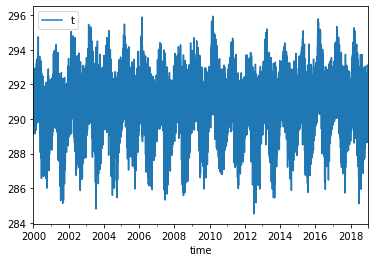

In [ ]:
df.plot()

In [ ]:
# Let's create a function that creates different features of time
def features(df):
  df['hour']=df.index.hour
  df['dayofweek']=df.index.dayofweek
  df['quarter'] = df.index.quarter
  df['month'] = df.index.month
  df['year'] = df.index.year
  df['dayofyear'] = df.index.dayofyear
  df['day'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

In [ ]:
features(df)

,t,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear
time,,,,,,,,,
2000-01-01 00:00:00,289.709595,0,5,1,1,2000,1,1,52
2000-01-01 01:00:00,289.709595,1,5,1,1,2000,1,1,52
2000-01-01 02:00:00,289.936493,2,5,1,1,2000,1,1,52
2000-01-01 03:00:00,289.818115,3,5,1,1,2000,1,1,52
2000-01-01 04:00:00,289.554230,4,5,1,1,2000,1,1,52
...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,291.087280,19,0,4,12,2018,365,31,1
2018-12-31 20:00:00,291.137939,20,0,4,12,2018,365,31,1
2018-12-31 21:00:00,291.158691,21,0,4,12,2018,365,31,1


In [ ]:
# Our training data will be from 2000 to 2015
train = df.loc[df.index<='01-01-2015']
# Our test data will be from 2015 to end (2018)
test = df.loc[df.index>'01-01-2015']

In [ ]:
# will have all the features of time that we created through the features function
X_train = train[['hour','dayofweek','quarter','month','year','dayofyear','day', 'weekofyear']]
# The target variable we want to predict for
y_train = train[['t']]
X_test = test[['hour','dayofweek','quarter','month','year','dayofyear','day', 'weekofyear']]
y_test = test[['t']]

In [ ]:
# We want to sort through various choices for random forest tuning and find the best one
param_grid = {
    'n_estimators':[5,10,15,20,50,100],
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_leaf': [1,2,3],
    'max_leaf_nodes': [10, 20, 30, 35, 50, 55]}
rf = RandomForestRegressor()
gs = GridSearchCV(rf, param_grid, cv=5)
gs.fit(X_train, y_train.values.ravel())

In [ ]:
# The best parameters that grid search found
print(gs.best_params_)

# The score for the best model
print(gs.best_score_)

In [ ]:
rfg = RandomForestRegressor(n_estimators = 50, max_depth = 20, max_leaf_nodes=55, min_samples_leaf=2, random_state = 0)

In [ ]:
rfg.fit(X_train, y_train.values.ravel())

RandomForestRegressor(max_depth=20, max_leaf_nodes=55, min_samples_leaf=2,
                      n_estimators=50, random_state=0)

In [ ]:
y_pred = rfg.predict(X_test)

In [ ]:
sqrt(mean_squared_error(y_test,y_pred))

1.104300445026087

###Feature Importance

In [ ]:
ft_imp = pd.Series(rfg.feature_importances_,index=X_test.columns).sort_values(ascending=False)
ft_imp

dayofyear     0.717396
hour          0.132301
year          0.110352
weekofyear    0.020276
day           0.014338
dayofweek     0.004478
month         0.000543
quarter       0.000315
dtype: float64

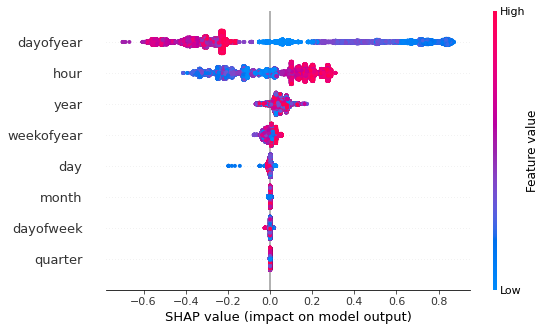

In [ ]:
explainer = shap.TreeExplainer(rfg)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

The colour scale looks at if the feature is high or lower. This is a dependence plot and it shows the importance of features on the model output. What does it tell us?

In [ ]:
explainer = shap.TreeExplainer(rfg)
shap_values = explainer.shap_values(X_test)
shap.initjs()
shap.force_plot(explainer.expected_value[:1000], shap_values[:1000], X_test)

Try exploring the Weather Bench dataset some more!

# If you have time, please fill out this feedback form: https://forms.gle/MJSMDWBizWcRP9vr7

## Thanks for checking this guide out! Congratulations on finishing.

### *Some additional resources to explore:*

**Climate Science/Modelling:**
* *Real Climate*, a climate science blog by experts: https://www.realclimate.org/
* Professor Steve Easterbrook's Blog, Serendipity: https://www.easterbrook.ca/steve/about/




Stephan Rasp, Peter D. Dueben, Sebastian Scher, Jonathan A. Weyn, Soukayna Mouatadid, and Nils Thuerey, 2020. WeatherBench: A benchmark dataset for data-driven weather forecasting. arXiv: https://arxiv.org/abs/2002.00469